In [58]:
# import python libraries.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [5]:
# import Dataset file
df = pd.read_csv('Diwali Sales Data.csv', encoding = 'unicode_escape')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [4]:
df.shape

(11251, 15)

In [6]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
# drop unrelated/blank columns
df.drop(['Status', 'unnamed1'], axis = 1, inplace= True)

In [10]:
# check for null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [11]:
# drop null values
df.dropna(inplace=True)

In [12]:
# Change data type
df['Amount'] = df['Amount'].astype('int')

In [13]:
df['Amount'].dtypes

dtype('int64')

In [14]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

# Exploratory Data Analysis

## Gender 

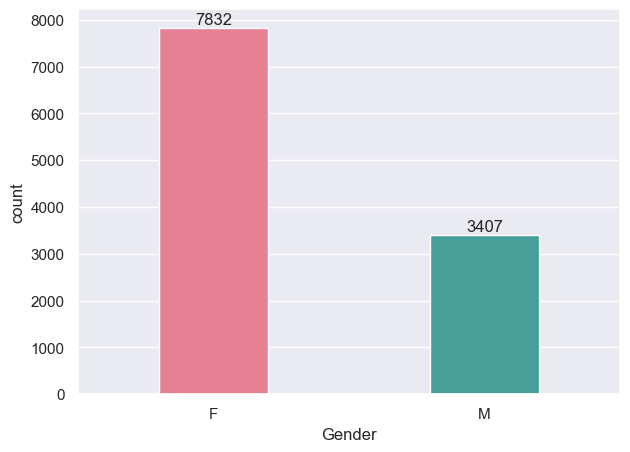

In [66]:
# plotting a bar chart for Gender and it's count.

ax = sns.countplot(x='Gender', data=df, palette='husl', width=0.4)
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

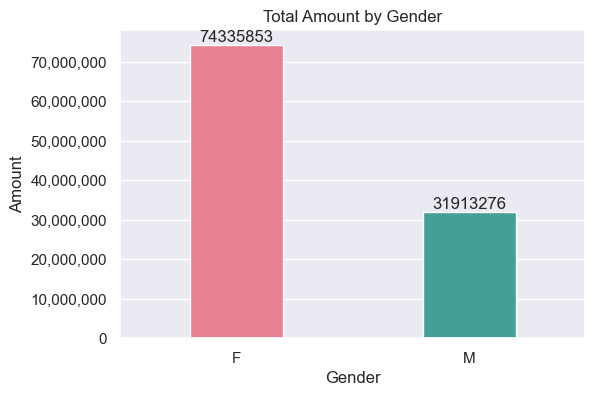

In [67]:
# plotting a bar chart for gender vs total amount

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(6,4))

ax = sns.barplot(x='Gender', y='Amount', data=sales_gen, 
                 palette='husl', width=0.4)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Total Amount by Gender')
plt.show()

### From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men

## Age 

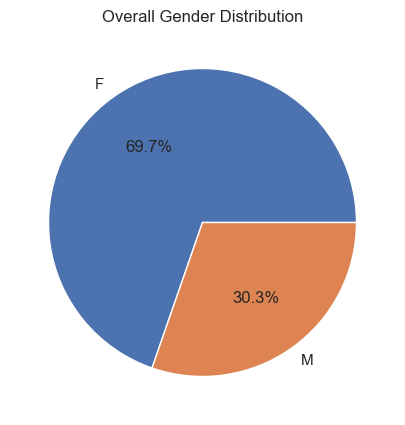

In [29]:
gender_counts = df['Gender'].value_counts()

plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Overall Gender Distribution')
plt.show()

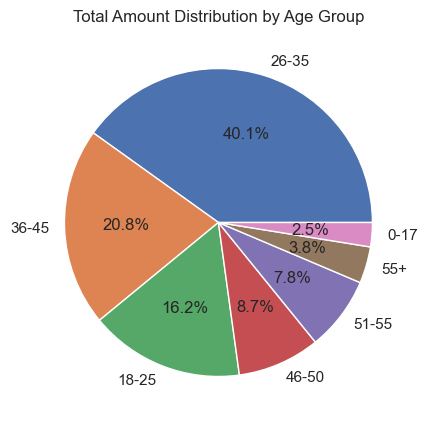

In [30]:
# Total Amount vs Age Group
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
plt.pie(sales_age['Amount'], labels=sales_age['Age Group'], autopct='%1.1f%%')
plt.title('Total Amount Distribution by Age Group')
plt.show()

### From above pie chart we can see that most of the buyers are of age group between 26-35 yrs female

### State 

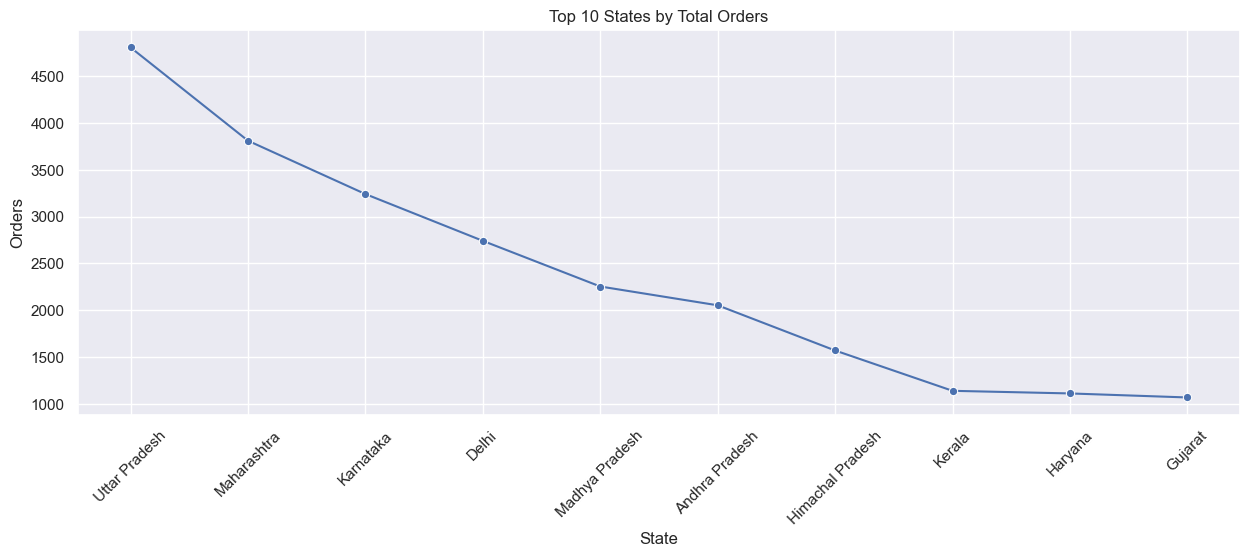

In [32]:
# total number of orders from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5)})
sns.lineplot(data=sales_state, x='State', y='Orders', marker='o')
plt.title('Top 10 States by Total Orders')
plt.xticks(rotation=45)
plt.show()

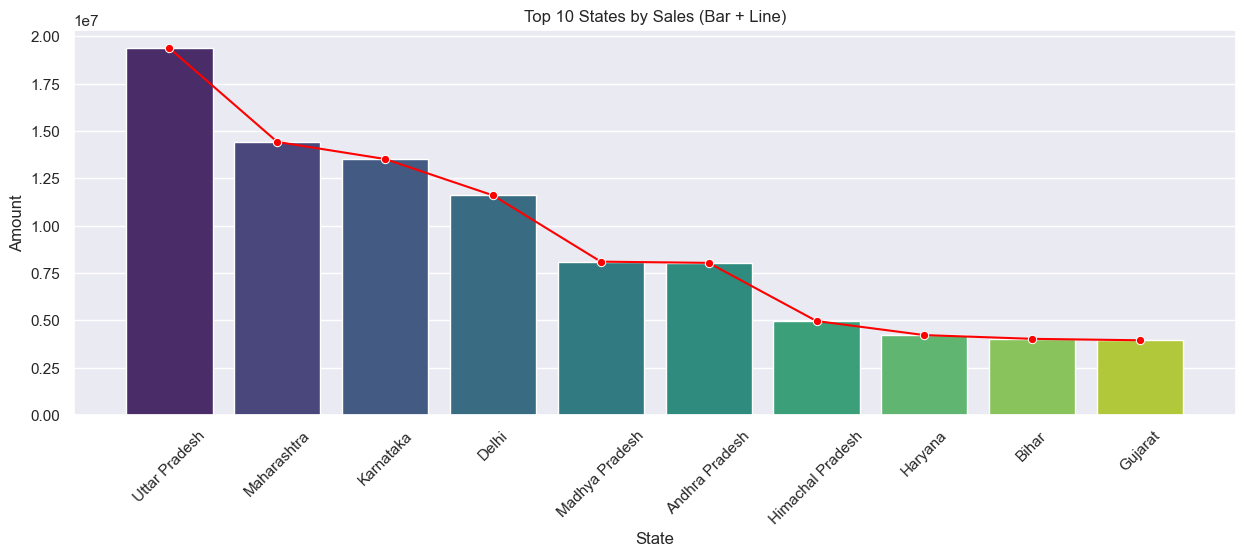

In [37]:
# total amount/sales from top 10 states


sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5)})
ax = sns.barplot(data=sales_state, x='State', y='Amount', palette='viridis')
sns.lineplot(data=sales_state, x='State', y='Amount', marker='o', color='red', ax=ax)
plt.title('Top 10 States by Sales (Bar + Line)')
plt.xticks(rotation=45)
plt.show()

### From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively

### Marital Status

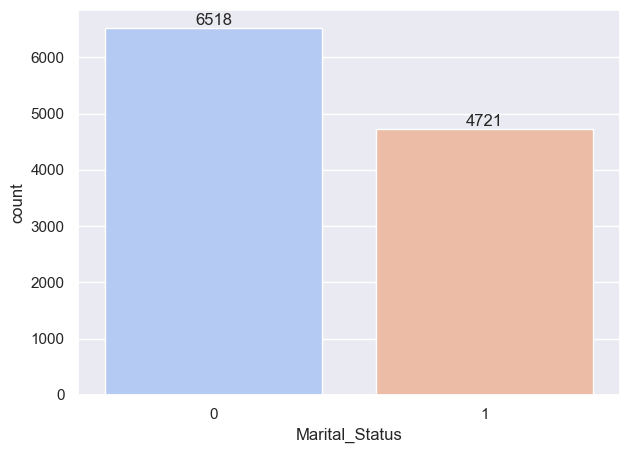

In [64]:
sns.set(rc={'figure.figsize':(7,5)})

ax = sns.countplot(data=df, x='Marital_Status', palette='coolwarm')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

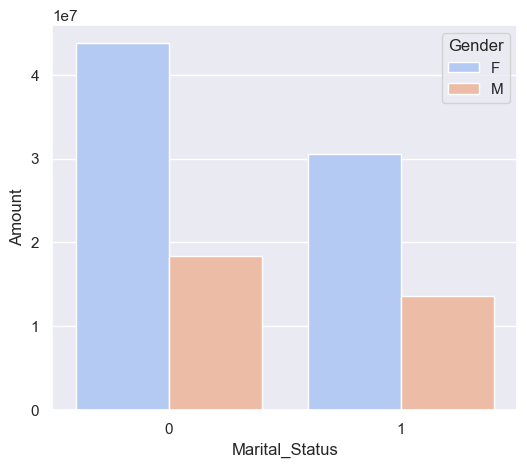

In [63]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data=sales_state, x='Marital_Status',  y='Amount',  hue='Gender',palette='coolwarm')  
plt.show()

### From above graphs we can see that most of the buyers are married (women) and they have high purchasing power

### Occupation

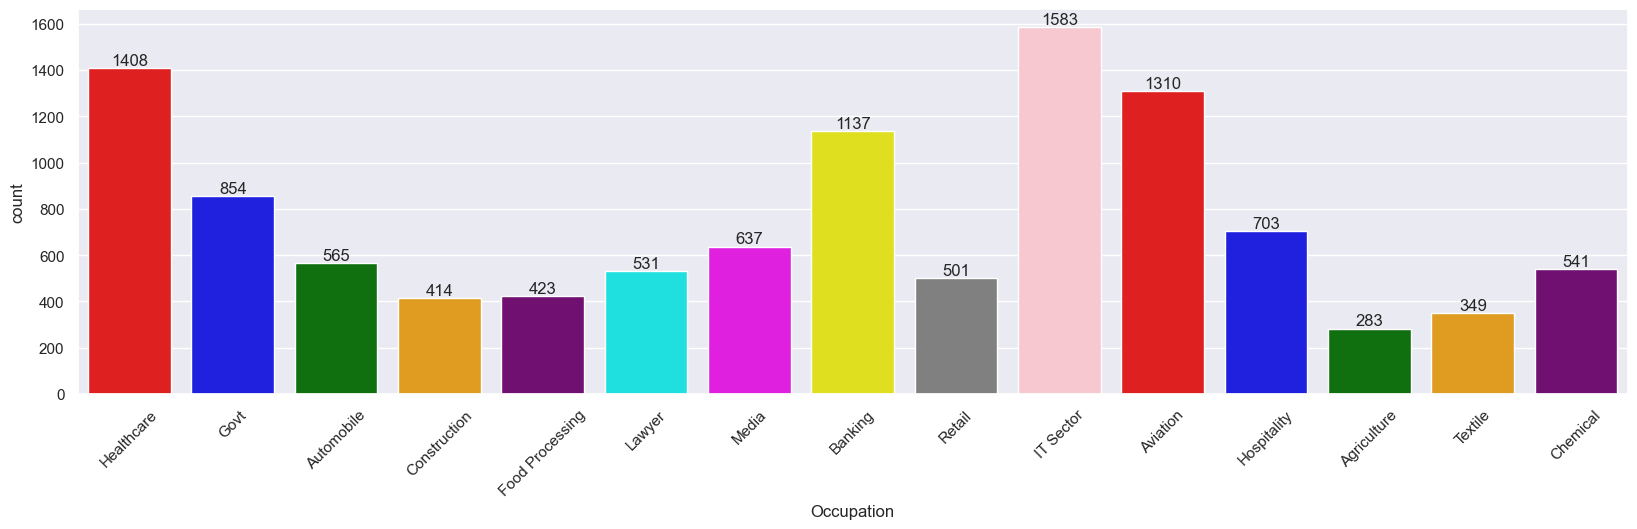

In [76]:
colors = ['red','blue','green','orange','purple','cyan','magenta','yellow','grey','pink']

ax = sns.countplot(data=df, x='Occupation', palette=colors)
for bars in ax.containers:
    ax.bar_label(bars)

plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Occupation', ylabel='Amount'>

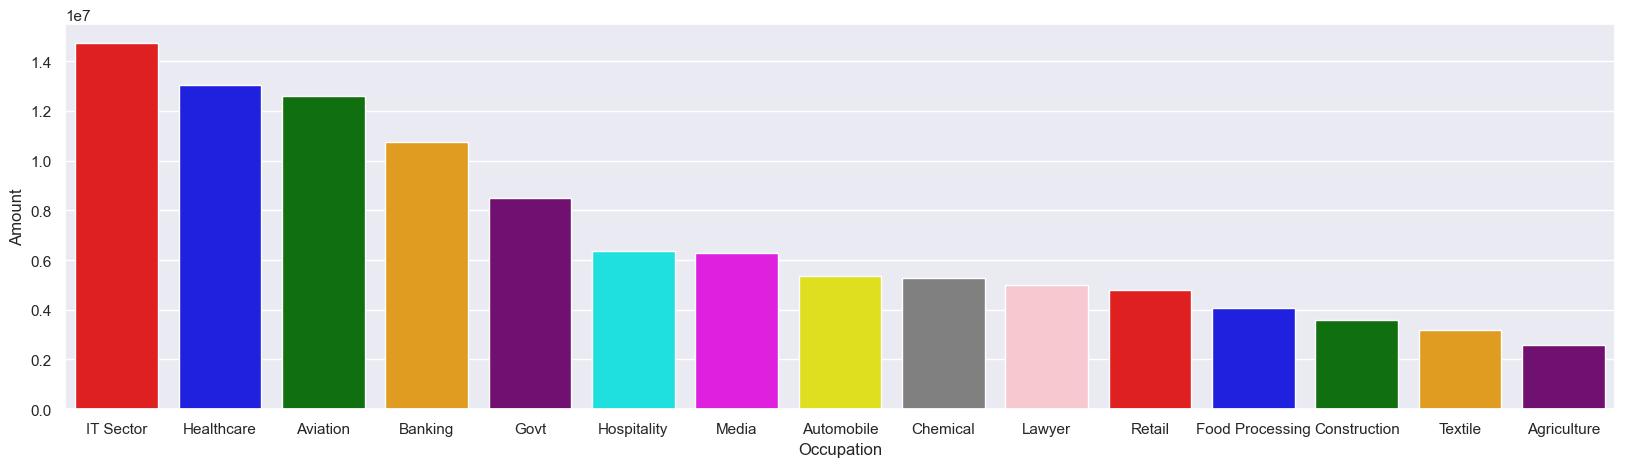

In [77]:
colors = ['red','blue','green','orange','purple','cyan','magenta','yellow','grey','pink']

sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount', palette=colors)

### From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector

### Product Category

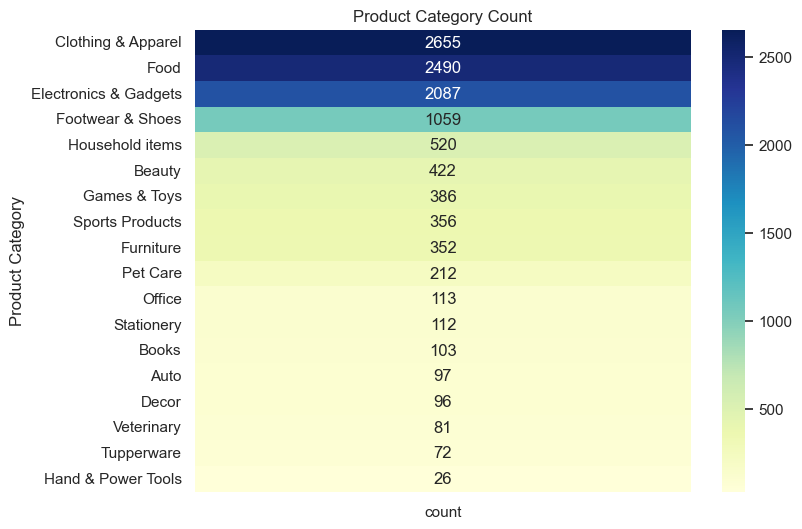

In [82]:
data = df['Product_Category'].value_counts().to_frame()

plt.figure(figsize=(8,6))
sns.heatmap(data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Product Category Count')
plt.ylabel('Product Category')
plt.show()

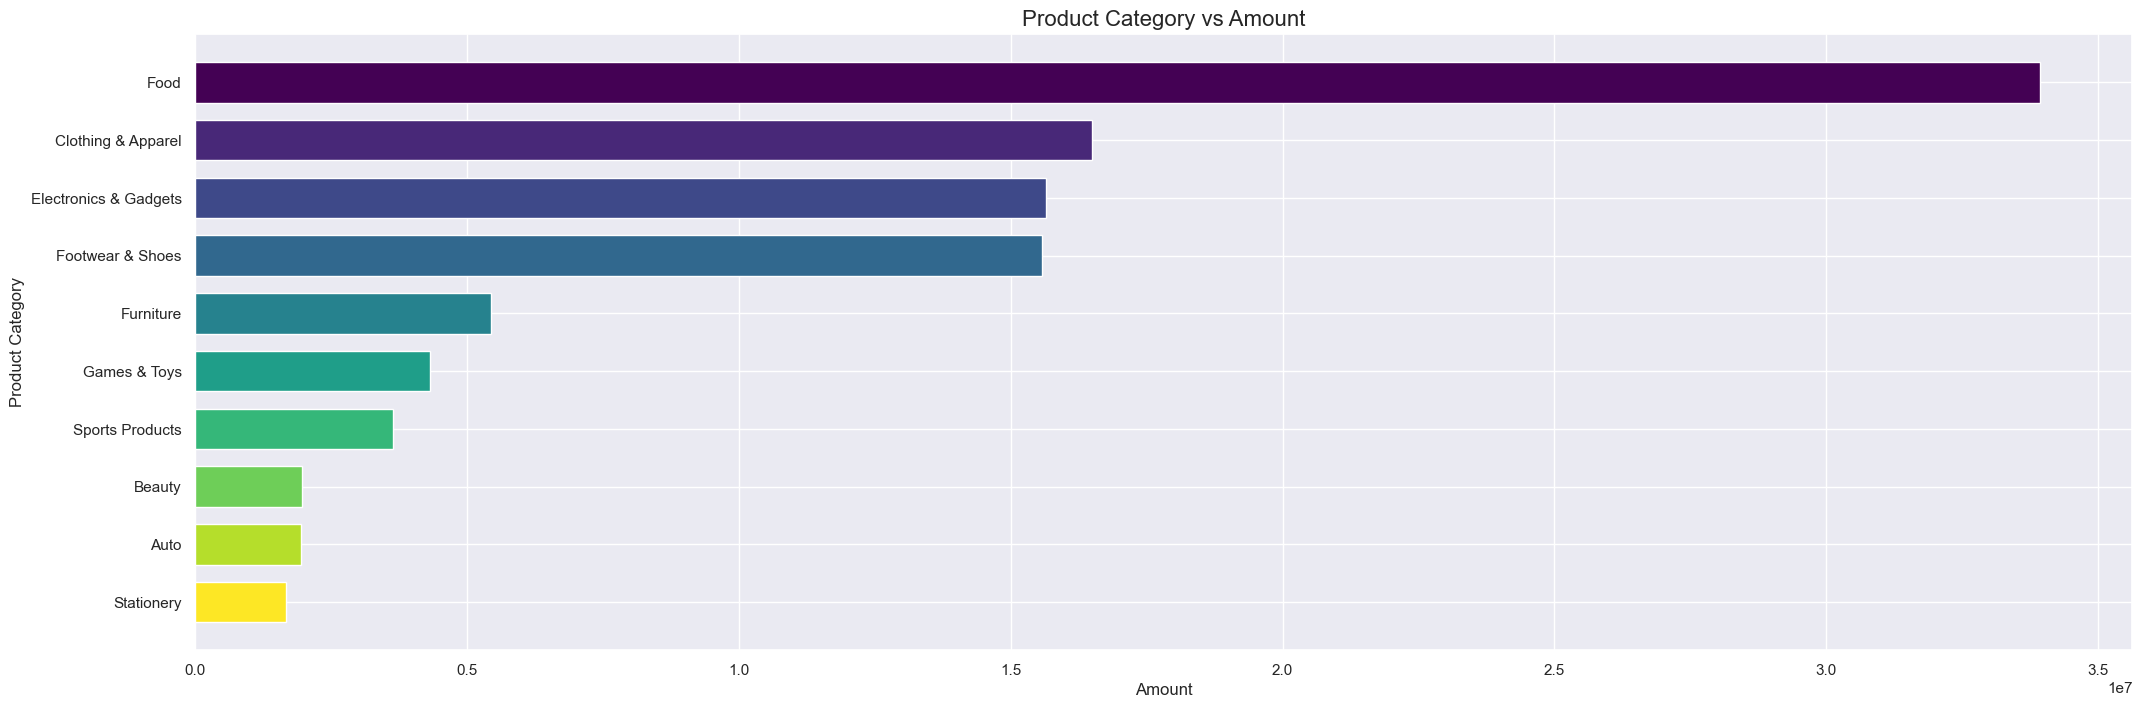

In [89]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

plt.figure(figsize=(25,8)) 
colors = plt.cm.viridis(np.linspace(0, 1, len(sales_state)))
plt.barh(sales_state['Product_Category'], sales_state['Amount'], color=colors, height=0.7)   
plt.title('Product Category vs Amount', fontsize=16)
plt.xlabel('Amount', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.gca().invert_yaxis()

plt.show()

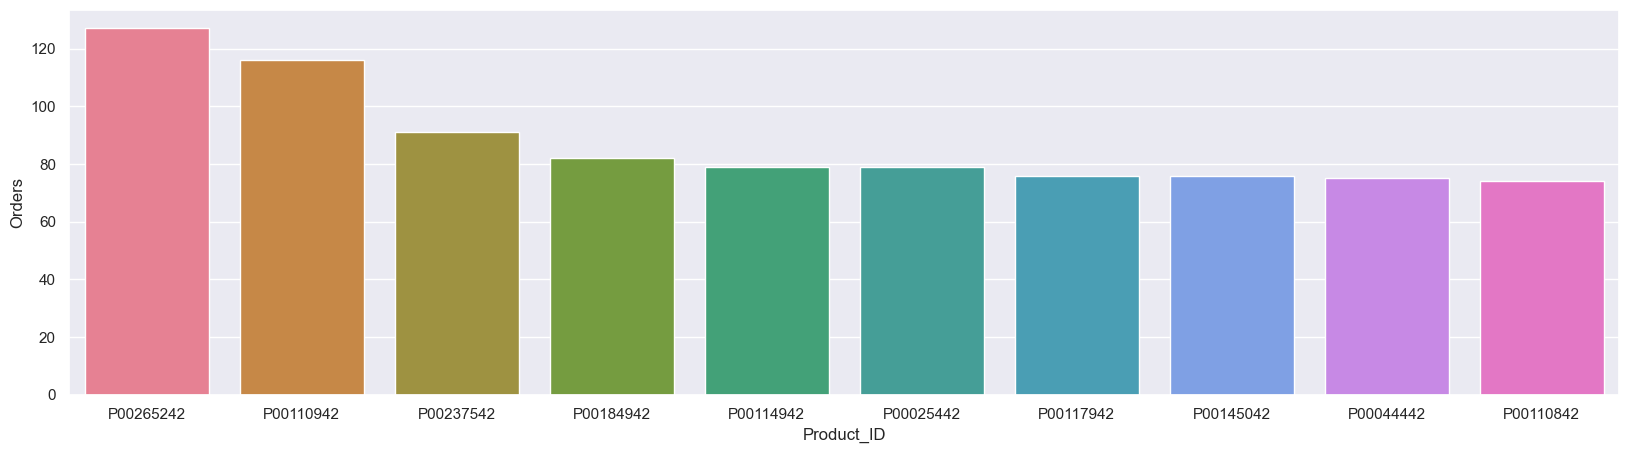

In [94]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_state, x='Product_ID', y='Orders',palette='husl')   
plt.show()

## Conclusion:

## Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category

## Thank You!